# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**
Name: Ashwani Kumar

College: MMDU

Role: Data Scientist Intern — Celebal Technology

Week: 5 — RNN, LSTM, GRU

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [17]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [18]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [19]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [20]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [21]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

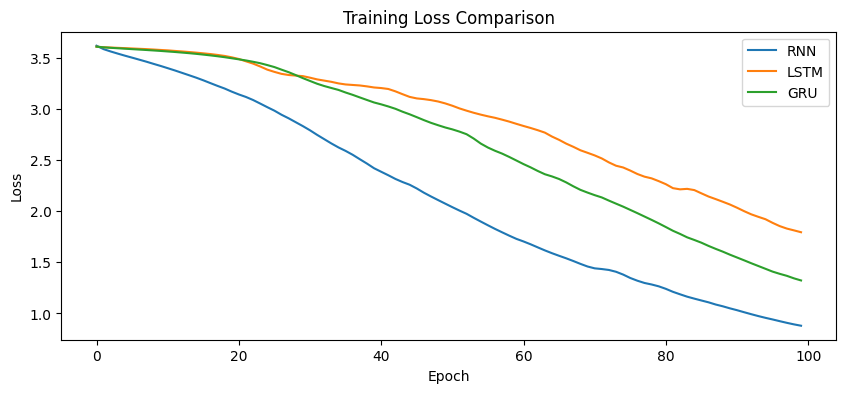

In [22]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [23]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [24]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is can artificial meaningful sentences
LSTM: deep learning is transforming artificial intelligence intelligence
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

In [25]:
# ── TASK 1: Custom Corpus ────────────────────────────────────
my_corpus = '''
ashwani is learning data science at celebal technology
data science combines statistics programming and domain knowledge
machine learning models learn patterns from historical data
deep learning uses neural networks with multiple layers
recurrent networks remember previous information in sequences
'''
print(my_corpus)

# Tokenize the new corpus
my_tokenizer = Tokenizer()
my_tokenizer.fit_on_texts([my_corpus])
my_total_words = len(my_tokenizer.word_index) + 1
print("My Vocabulary size:", my_total_words)


ashwani is learning data science at celebal technology
data science combines statistics programming and domain knowledge
machine learning models learn patterns from historical data
deep learning uses neural networks with multiple layers
recurrent networks remember previous information in sequences

My Vocabulary size: 34


In [26]:
# ── TASK 2: Increase Embedding Dimension (32 → 100) ──────────
rnn_model_v2 = Sequential([
    Embedding(total_words, 100, input_length=max_len-1),  # 32 → 100
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model_v2.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

rnn_v2_history = rnn_model_v2.fit(X, y, epochs=50, verbose=0)
print("RNN with embedding=100 training completed")
print(f"Final loss: {rnn_v2_history.history['loss'][-1]:.4f}")

RNN with embedding=100 training completed
Final loss: 1.5035


In [ ]:
# ── TASK 3: Increase Epochs (100 → 200) ──────────────────────
lstm_model_200ep = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model_200ep.compile(loss='sparse_categorical_crossentropy',
                         optimizer='adam',
                         metrics=['accuracy'])

lstm_200ep_history = lstm_model_200ep.fit(X, y, epochs=200, verbose=0)
print("LSTM trained for 200 epochs")
print(f"Final loss: {lstm_200ep_history.history['loss'][-1]:.4f}")
print(f"Original LSTM (100 epochs) loss: {lstm_history.history['loss'][-1]:.4f}")

In [ ]:
# ── TASK 4: Change Hidden Units (64 → 128) ───────────────────
gru_model_128 = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(128),   # 64 → 128
    Dense(total_words, activation='softmax')
])

gru_model_128.compile(loss='sparse_categorical_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])

gru_128_history = gru_model_128.fit(X, y, epochs=100, verbose=0)
print("GRU with 128 hidden units training completed")
print(f"Final loss: {gru_128_history.history['loss'][-1]:.4f}")
print(f"Original GRU (64 units) loss: {gru_history.history['loss'][-1]:.4f}")

In [ ]:
# ── TASK 5: Generate 10 words instead of 5 ───────────────────
print("RNN (10 words) :", generate_text(rnn_model, "deep learning", next_words=10))
print("LSTM (10 words):", generate_text(lstm_model, "deep learning", next_words=10))
print("GRU (10 words) :", generate_text(gru_model, "deep learning", next_words=10))

In [ ]:
# ── FINAL COMPARISON TABLE ───────────────────────────────────
import pandas as pd

summary = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU",
              "RNN (embed=100)", "LSTM (200 epochs)", "GRU (128 units)"],
    "Final Loss": [
        round(rnn_history.history['loss'][-1], 4),
        round(lstm_history.history['loss'][-1], 4),
        round(gru_history.history['loss'][-1], 4),
        round(rnn_v2_history.history['loss'][-1], 4),
        round(lstm_200ep_history.history['loss'][-1], 4),
        round(gru_128_history.history['loss'][-1], 4)
    ]
})
print(summary.to_string(index=False))

## Final Insights

### Model Comparison
- Vanilla RNN: Learns short-term patterns but struggles with long-range dependencies due to vanishing gradients
- LSTM: Uses input, forget and output gates to preserve long-term memory — best for grammar dependencies
- GRU: Simpler architecture (reset + update gates), trains faster, gives similar results to LSTM

### Task Observations
- Increasing embedding dimension (32→100) improved RNN's ability to represent word relationships
- Training for 200 epochs reduced LSTM loss further but with diminishing returns after a point
- Increasing hidden units (64→128) gave GRU more capacity to learn complex patterns
- Generating 10 words instead of 5 showed how errors can compound in longer sequences

### Key Learning
LSTM and GRU outperform vanilla RNN for text generation tasks because their gating
mechanisms allow them to selectively remember or forget information over longer sequences,
solving the vanishing gradient problem that limits vanilla RNN.

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**